In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# For text preprocessing
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# For deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Embedding, Input, Flatten
from tensorflow.keras.layers import BatchNormalization, SpatialDropout1D, Bidirectional, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Concatenate # Explicitly import for the model definition below

# For evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.utils import class_weight

# For learning curve analysis
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import learning_curve

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Helper function for KerasClassifier (re-defining the model architecture without compilation) ---
# This is necessary because KerasClassifier expects a function that returns an UNCOMPILED Keras model.
# The `create_multi_filter_cnn` function defined previously returns a COMPILED model.
def build_uncompiled_cnn_model(vocab_size, embedding_dim, max_length, num_classes):
    # Input layer
    input_layer = Input(shape=(max_length,))

    # Embedding layer
    embedding = Embedding(vocab_size, embedding_dim, input_length=max_length)(input_layer)
    embedding = SpatialDropout1D(0.3)(embedding)

    # Multiple Conv1D with different kernel sizes
    conv1 = Conv1D(128, 2, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv1 = BatchNormalization()(conv1)
    conv1 = GlobalMaxPooling1D()(conv1)

    conv2 = Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv2 = BatchNormalization()(conv2)
    conv2 = GlobalMaxPooling1D()(conv2)

    conv3 = Conv1D(128, 4, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv3 = BatchNormalization()(conv3)
    conv3 = GlobalMaxPooling1D()(conv3)

    conv4 = Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv4 = BatchNormalization()(conv4)
    conv4 = GlobalMaxPooling1D()(conv4)

    # Concatenate all conv outputs
    concatenated = Concatenate()([conv1, conv2, conv3, conv4])
    concatenated = Dropout(0.4)(concatenated)

    # Dense layers
    dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(concatenated)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.5)(dense1)

    dense2 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dense1)
    dense2 = BatchNormalization()(dense2)
    dense2 = Dropout(0.5)(dense2)

    # Output layer
    output_layer = Dense(num_classes, activation='softmax')(dense2)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    return model

# --- Patch KerasClassifier for scikit-learn compatibility ---
# This addresses `AttributeError: 'super' object has no attribute '__sklearn_tags__'`
# that occurs when scikit-learn tries to get tags from KerasClassifier.
# We will define __sklearn_tags__ as a property to directly return the tags,
# ensuring it doesn't call super() and bypasses any problematic inheritance chain.
if not hasattr(KerasClassifier, '_patched_for_sklearn_tags_issue'):
    @property
    def _sklearn_tags(self):
        return {
            "estimator_type": "classifier",
            "binary_only": False,
            "requires_y": True,
            "requires_positive_X": False,
            "array_api_input": False,
            "allow_nan": False,
            "sparse_input": False,
            "custom_info": {},
        }
    KerasClassifier.__sklearn_tags__ = _sklearn_tags
    KerasClassifier._patched_for_sklearn_tags_issue = True # Mark as patched

# --- Code for generating and plotting learning curve ---

# 1. Create a KerasClassifier instance using the uncompiled model builder
kc_model = KerasClassifier(
    model=build_uncompiled_cnn_model,
    model__vocab_size=MAX_VOCAB_SIZE,
    model__embedding_dim=EMBEDDING_DIM,
    model__max_length=MAX_SEQUENCE_LENGTH,
    model__num_classes=len(label_encoder.classes_),
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    fit__verbose=0, # Suppress training output during learning curve calculation
    fit__epochs=10, # Limiting epochs for faster learning curve computation (adjust as needed)
    fit__batch_size=32,
    fit__class_weight=class_weight_dict # Pass class weights to fit method
)

# Explicitly set the estimator type for scikit-learn compatibility (this alone was not sufficient)
kc_model._estimator_type = 'classifier'

# 2. Generate learning curve data
# This step is computationally expensive. Using a smaller number of train_sizes and cv folds.
train_sizes, train_scores, test_scores = learning_curve(
    estimator=kc_model,
    X=X_train_pad,
    y=y_train,
    cv=3, # Using 3-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    train_sizes=np.linspace(0.1, 1.0, 5), # 5 different training set sizes from 10% to 100%
    scoring='accuracy',
    verbose=0
)

# 3. Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 4. Plot the learning curve
plt.figure(figsize=(10, 7))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title("Learning Curve (CNN Model)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_sklearn.png', dpi=300, bbox_inches='tight')
plt.show()

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [2]:
# Load the dataset
df = pd.read_excel('/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst few rows:")
df.head()

Dataset Shape: (82611, 3)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82611 entries, 0 to 82610
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Comment       82606 non-null  object
 1   Category      82611 non-null  object
 2   Cleaned_Text  82270 non-null  object
dtypes: object(3)
memory usage: 1.9+ MB

First few rows:


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


Category Distribution (Original):
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Percentage Distribution:
Category
Negative    50.059919
Positive    49.940081
Name: proportion, dtype: float64


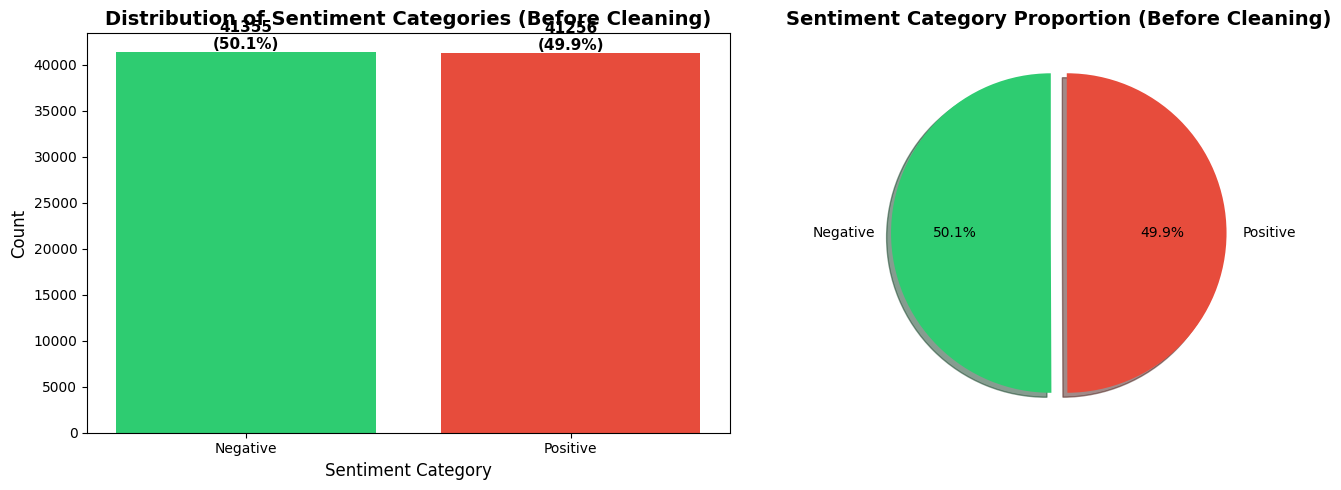

In [3]:
# Display category distribution before cleaning
print("Category Distribution (Original):")
print(df['Category'].value_counts())
print("\nPercentage Distribution:")
print(df['Category'].value_counts(normalize=True) * 100)

# Visualize category distribution before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
ax1 = axes[0]
counts = df['Category'].value_counts()
bars = ax1.bar(counts.index, counts.values, color=colors)
ax1.set_xlabel('Sentiment Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Sentiment Categories (Before Cleaning)', fontsize=14, fontweight='bold')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
explode = (0.05, 0.05)
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        explode=explode, colors=colors, startangle=90, shadow=True)
ax2.set_title('Sentiment Category Proportion (Before Cleaning)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution_before.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Drop rows with missing values if any
df = df.dropna(subset=['Cleaned_Text', 'Category'])
print(f"\nShape after dropping missing values: {df.shape}")

Missing values in each column:
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Shape after dropping missing values: (82270, 3)


In [5]:
# Define Bangla text cleaning function
def clean_bangla_text(text):
    """
    Clean Bangla text by removing unnecessary characters and normalizing
    """
    if not isinstance(text, str):
        return ""

    # Convert to string if not already
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text)

    # Remove leading/trailing whitespaces
    text = text.strip()

    # Remove any remaining English punctuation that might interfere
    # But keep Bangla characters
    bangla_pattern = re.compile(r'[^\u0980-\u09FF\s]')
    text = bangla_pattern.sub('', text)

    # Remove extra spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['Cleaned_Text'] = df['Cleaned_Text'].apply(clean_bangla_text)

# Remove empty texts after cleaning
df = df[df['Cleaned_Text'].str.len() > 0]
print(f"Shape after removing empty texts: {df.shape}")

Shape after removing empty texts: (82227, 3)


Text Length Statistics:
count    82227.000000
mean        33.580077
std         36.388851
min          1.000000
25%         13.000000
50%         24.000000
75%         41.000000
max       1419.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    82227.000000
mean         6.634475
std          6.779882
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max        270.000000
Name: word_count, dtype: float64


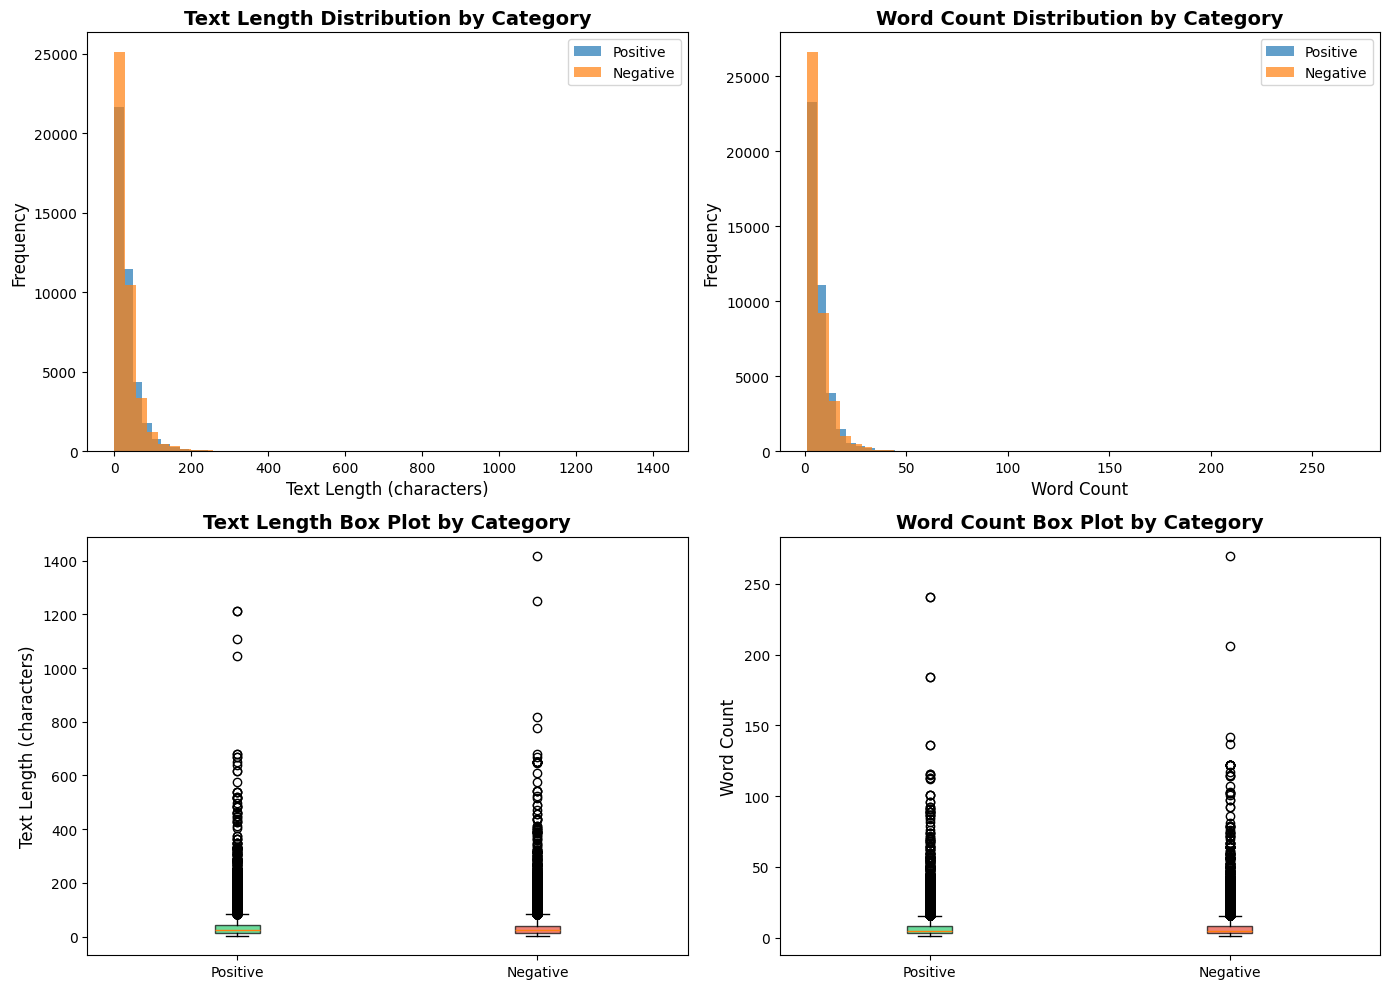

In [6]:
# Display text length statistics
df['text_length'] = df['Cleaned_Text'].apply(len)
df['word_count'] = df['Cleaned_Text'].apply(lambda x: len(x.split()))

print("Text Length Statistics:")
print(df['text_length'].describe())
print("\nWord Count Statistics:")
print(df['word_count'].describe())

# Visualize text length distribution by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Text length histogram
ax1 = axes[0, 0]
for category in df['Category'].unique():
    subset = df[df['Category'] == category]['text_length']
    ax1.hist(subset, alpha=0.7, label=category, bins=50)
ax1.set_xlabel('Text Length (characters)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Text Length Distribution by Category', fontsize=14, fontweight='bold')
ax1.legend()

# Word count histogram
ax2 = axes[0, 1]
for category in df['Category'].unique():
    subset = df[df['Category'] == category]['word_count']
    ax2.hist(subset, alpha=0.7, label=category, bins=50)
ax2.set_xlabel('Word Count', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Word Count Distribution by Category', fontsize=14, fontweight='bold')
ax2.legend()

# Box plot for text length
ax3 = axes[1, 0]
data_by_cat = [df[df['Category'] == cat]['text_length'].values for cat in df['Category'].unique()]
bp1 = ax3.boxplot(data_by_cat, labels=df['Category'].unique(), patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Text Length (characters)', fontsize=12)
ax3.set_title('Text Length Box Plot by Category', fontsize=14, fontweight='bold')

# Box plot for word count
ax4 = axes[1, 1]
data_by_cat_wc = [df[df['Category'] == cat]['word_count'].values for cat in df['Category'].unique()]
bp2 = ax4.boxplot(data_by_cat_wc, labels=df['Category'].unique(), patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel('Word Count', fontsize=12)
ax4.set_title('Word Count Box Plot by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Additional Bangla specific preprocessing
def preprocess_bangla_text(text):
    """
    Additional preprocessing specific to Bangla text
    """
    if not isinstance(text, str):
        return ""

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove standalone punctuation/digits (keep only Bangla characters and spaces)
    # Keep basic Bangla Unicode range: 0980-09FF
    bangla_chars = re.compile(r'[^\u0980-\u09FF\s]')
    text = bangla_chars.sub('', text)

    # Remove extra spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Cleaned_Text'] = df['Cleaned_Text'].apply(preprocess_bangla_text)
df = df[df['Cleaned_Text'].str.len() > 0]
print(f"Shape after final preprocessing: {df.shape}")

Shape after final preprocessing: (82227, 5)


In [8]:
# Display cleaned data samples
print("Sample of cleaned data:")
print("-" * 80)
for i in range(10):
    print(f"Text: {df.iloc[i]['Cleaned_Text'][:100]}...")
    print(f"Category: {df.iloc[i]['Category']}")
    print("-" * 40)

Sample of cleaned data:
--------------------------------------------------------------------------------
Text: মন হয় পাড়া মহল্ল খেলা দেখ...
Category: Positive
----------------------------------------
Text: বাংলাদেশ ফুটবল খালা কুত কুত খেললে...
Category: Positive
----------------------------------------
Text: বাংলাদেশ দাম ছালা খেল...
Category: Positive
----------------------------------------
Text: সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা...
Category: Positive
----------------------------------------
Text: খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন যা দাখা এমনি হ লাস্ট মোমেন্ প্রমান...
Category: Positive
----------------------------------------
Text: দন খেলা বাংলা দেশ...
Category: Positive
----------------------------------------
Text: থার্ড ক্লাস বল কন্ট্রোলিং বাংলাদেশ ভুল পাস...
Category: Positive
----------------------------------------
Text: বাল খেলা দেইখা টাকা লস করলাম বিড়ি খাইলে ভালো ছিলো...
Category: Positive
----------------------------------------
Text: কোচটা হিরনচির ম

In [9]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Category'])

print("Label Encoding Mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category} -> {i}")

# Display category distribution after cleaning
print("\nCategory Distribution (After Cleaning):")
print(df['Category'].value_counts())

Label Encoding Mapping:
Negative -> 0
Positive -> 1

Category Distribution (After Cleaning):
Category
Negative    41138
Positive    41089
Name: count, dtype: int64


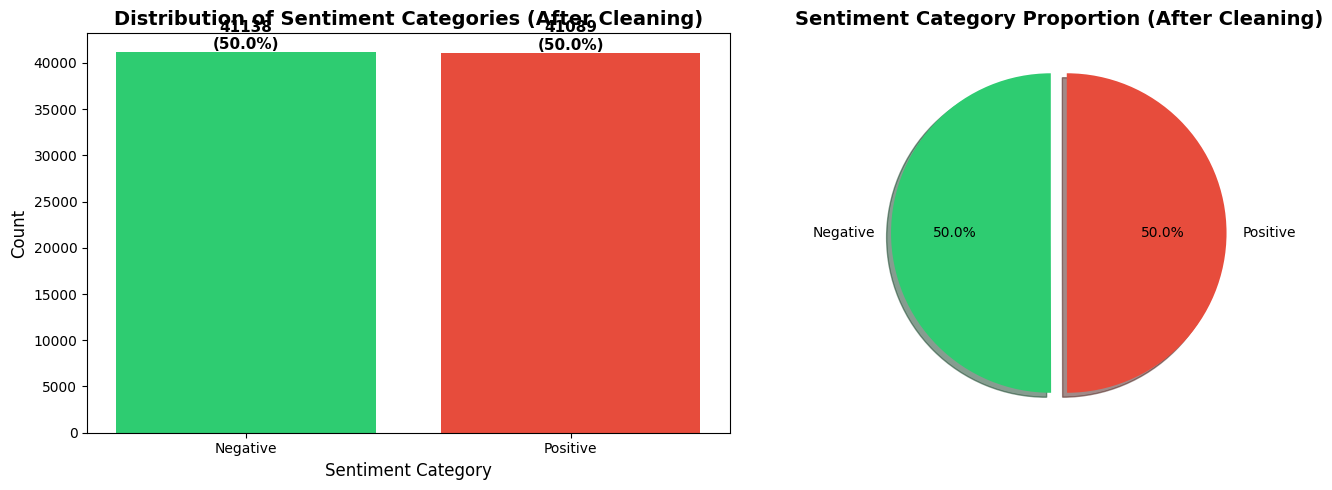

In [10]:
# Visualize category distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1 = axes[0]
counts_after = df['Category'].value_counts()
bars = ax1.bar(counts_after.index, counts_after.values, color=colors)
ax1.set_xlabel('Sentiment Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Sentiment Categories (After Cleaning)', fontsize=14, fontweight='bold')
for bar, count in zip(bars, counts_after.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.pie(counts_after.values, labels=counts_after.index, autopct='%1.1f%%',
        explode=explode, colors=colors, startangle=90, shadow=True)
ax2.set_title('Sentiment Category Proportion (After Cleaning)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution_after.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Prepare data for tokenization
texts = df['Cleaned_Text'].values
labels = df['label'].values

# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u} ({label_encoder.classes_[u]}): {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest set distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u} ({label_encoder.classes_[u]}): {c} ({c/len(y_test)*100:.1f}%)")

Training set size: 65781
Test set size: 16446

Training set distribution:
Class 0 (Negative): 32910 (50.0%)
Class 1 (Positive): 32871 (50.0%)

Test set distribution:
Class 0 (Negative): 8228 (50.0%)
Class 1 (Positive): 8218 (50.0%)


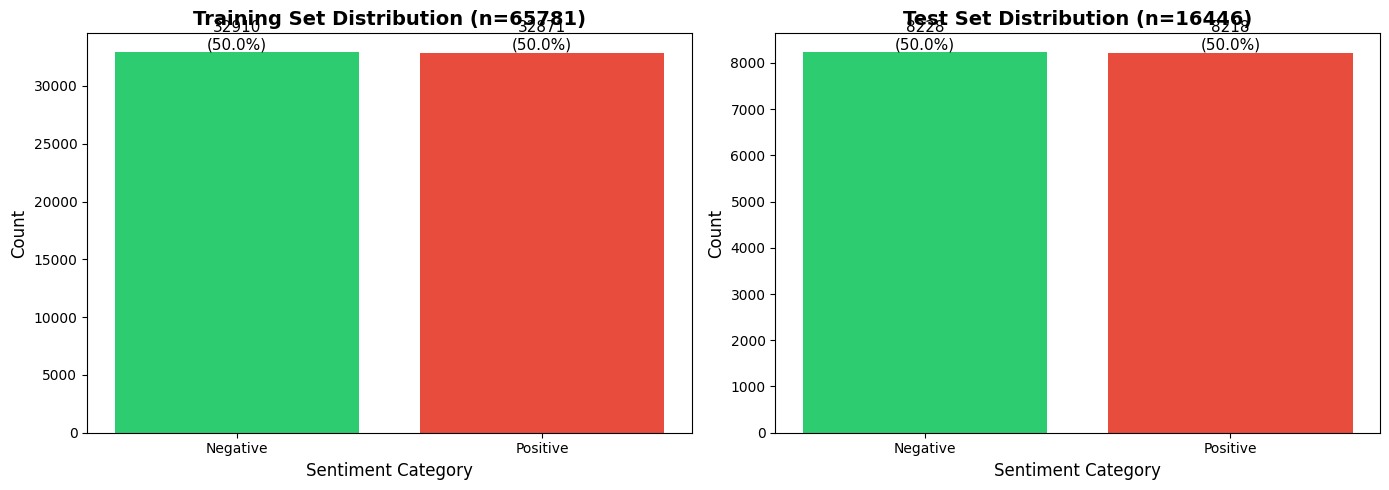

In [12]:
# Visualize train-test split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
ax1 = axes[0]
train_counts = pd.Series(y_train).value_counts().sort_index()
train_labels = [label_encoder.classes_[i] for i in train_counts.index]
bars1 = ax1.bar(train_labels, train_counts.values, color=colors)
ax1.set_xlabel('Sentiment Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title(f'Training Set Distribution (n={len(y_train)})', fontsize=14, fontweight='bold')
for bar, count in zip(bars1, train_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(y_train)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# Test set distribution
ax2 = axes[1]
test_counts = pd.Series(y_test).value_counts().sort_index()
test_labels = [label_encoder.classes_[i] for i in test_counts.index]
bars2 = ax2.bar(test_labels, test_counts.values, color=colors)
ax2.set_xlabel('Sentiment Category', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'Test Set Distribution (n={len(y_test)})', fontsize=14, fontweight='bold')
for bar, count in zip(bars2, test_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(y_test)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

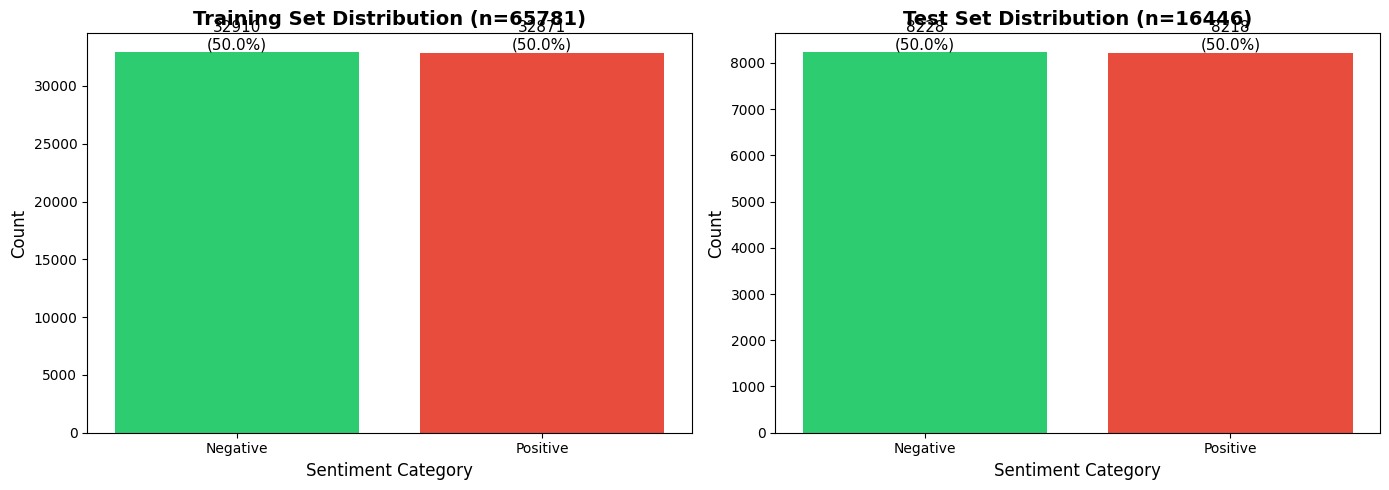

In [13]:
# Visualize train-test split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
ax1 = axes[0]
train_counts = pd.Series(y_train).value_counts().sort_index()
train_labels = [label_encoder.classes_[i] for i in train_counts.index]
bars1 = ax1.bar(train_labels, train_counts.values, color=colors)
ax1.set_xlabel('Sentiment Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title(f'Training Set Distribution (n={len(y_train)})', fontsize=14, fontweight='bold')
for bar, count in zip(bars1, train_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(y_train)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# Test set distribution
ax2 = axes[1]
test_counts = pd.Series(y_test).value_counts().sort_index()
test_labels = [label_encoder.classes_[i] for i in test_counts.index]
bars2 = ax2.bar(test_labels, test_counts.values, color=colors)
ax2.set_xlabel('Sentiment Category', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'Test Set Distribution (n={len(y_test)})', fontsize=14, fontweight='bold')
for bar, count in zip(bars2, test_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(y_test)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Tokenization parameters
MAX_VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 100  # Based on word count analysis
EMBEDDING_DIM = 200

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")

# Display some statistics about sequence lengths
seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nSequence length statistics (before padding):")
print(f"Mean: {np.mean(seq_lengths):.2f}")
print(f"Median: {np.median(seq_lengths):.2f}")
print(f"Max: {np.max(seq_lengths)}")
print(f"95th percentile: {np.percentile(seq_lengths, 95):.2f}")

Vocabulary size: 26997
Training sequences shape: (65781, 100)
Test sequences shape: (16446, 100)

Sequence length statistics (before padding):
Mean: 6.64
Median: 5.00
Max: 270
95th percentile: 17.00


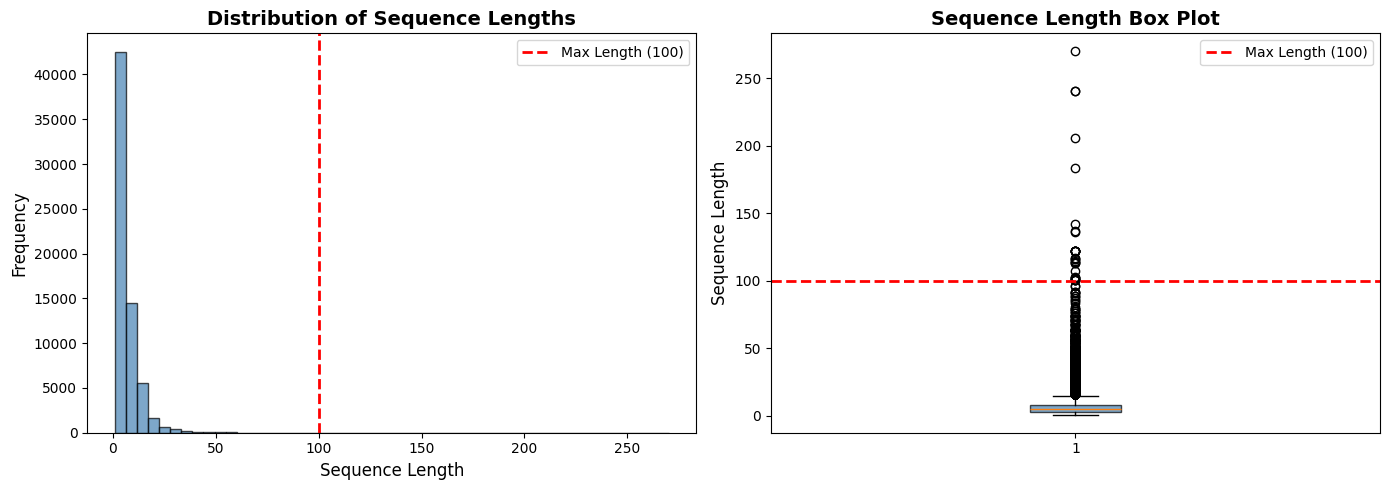

In [15]:
# Visualize sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sequence lengths
ax1 = axes[0]
ax1.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', linewidth=2, label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
ax1.set_xlabel('Sequence Length', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Sequence Lengths', fontsize=14, fontweight='bold')
ax1.legend()

# Box plot
ax2 = axes[1]
ax2.boxplot(seq_lengths, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
ax2.set_ylabel('Sequence Length', fontsize=12)
ax2.set_title('Sequence Length Box Plot', fontsize=14, fontweight='bold')
ax2.axhline(y=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', linewidth=2, label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
ax2.legend()

plt.tight_layout()
plt.savefig('sequence_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

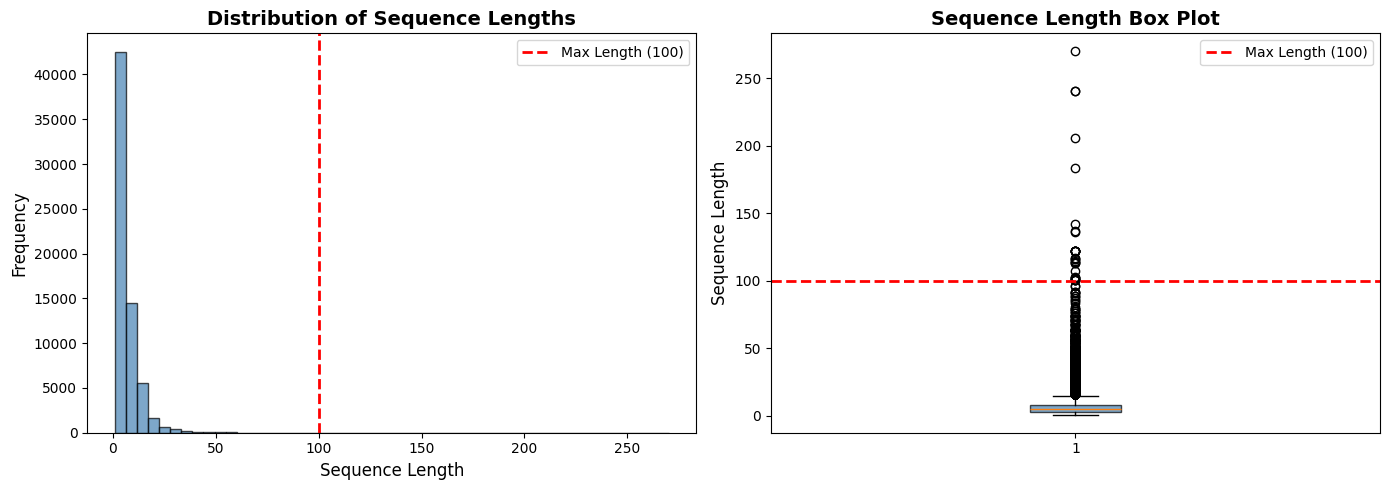

In [16]:
# Visualize sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sequence lengths
ax1 = axes[0]
ax1.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', linewidth=2, label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
ax1.set_xlabel('Sequence Length', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Sequence Lengths', fontsize=14, fontweight='bold')
ax1.legend()

# Box plot
ax2 = axes[1]
ax2.boxplot(seq_lengths, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
ax2.set_ylabel('Sequence Length', fontsize=12)
ax2.set_title('Sequence Length Box Plot', fontsize=14, fontweight='bold')
ax2.axhline(y=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', linewidth=2, label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
ax2.legend()

plt.tight_layout()
plt.savefig('sequence_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Calculate class weights for handling imbalanced data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights for handling imbalance:")
for i, weight in class_weight_dict.items():
    print(f"Class {i} ({label_encoder.classes_[i]}): {weight:.3f}")

Class weights for handling imbalance:
Class 0 (Negative): 0.999
Class 1 (Positive): 1.001


In [18]:
# Build CNN Model with regularization to prevent overfitting
def create_cnn_model(vocab_size, embedding_dim, max_length, num_classes):
    """
    Create a CNN model for text classification
    """
    model = Sequential([
        # Embedding layer
        Embedding(vocab_size, embedding_dim, input_length=max_length),

        # Spatial Dropout for regularization
        SpatialDropout1D(0.3),

        # First Conv1D block
        Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dropout(0.4),

        # Dense layers
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),

        # Output layer
        Dense(num_classes, activation='softmax')
    ])

    return model

# Alternative: Multi-filter CNN Model (more powerful)
def create_multi_filter_cnn(vocab_size, embedding_dim, max_length, num_classes):
    """
    Create a CNN model with multiple filter sizes
    """
    from tensorflow.keras.layers import Concatenate

    # Input layer
    input_layer = Input(shape=(max_length,))

    # Embedding layer
    embedding = Embedding(vocab_size, embedding_dim, input_length=max_length)(input_layer)
    embedding = SpatialDropout1D(0.3)(embedding)

    # Multiple Conv1D with different kernel sizes
    conv1 = Conv1D(128, 2, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv1 = BatchNormalization()(conv1)
    conv1 = GlobalMaxPooling1D()(conv1)

    conv2 = Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv2 = BatchNormalization()(conv2)
    conv2 = GlobalMaxPooling1D()(conv2)

    conv3 = Conv1D(128, 4, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv3 = BatchNormalization()(conv3)
    conv3 = GlobalMaxPooling1D()(conv3)

    conv4 = Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=l2(0.001))(embedding)
    conv4 = BatchNormalization()(conv4)
    conv4 = GlobalMaxPooling1D()(conv4)

    # Concatenate all conv outputs
    concatenated = Concatenate()([conv1, conv2, conv3, conv4])
    concatenated = Dropout(0.4)(concatenated)

    # Dense layers
    dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(concatenated)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.5)(dense1)

    dense2 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dense1)
    dense2 = BatchNormalization()(dense2)
    dense2 = Dropout(0.5)(dense2)

    # Output layer
    output_layer = Dense(num_classes, activation='softmax')(dense2)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    return model

# Create model (using multi-filter CNN for better performance)
model = create_multi_filter_cnn(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=len(label_encoder.classes_)
)

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 200)  │  3,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 100, 200)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 128)  │     76,928 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 128)  │    102,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 100, 128)  │    128,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ dropout[0][0]   

 Total params: 3,435,778 (13.11 MB)

 Trainable params: 3,434,370 (13.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

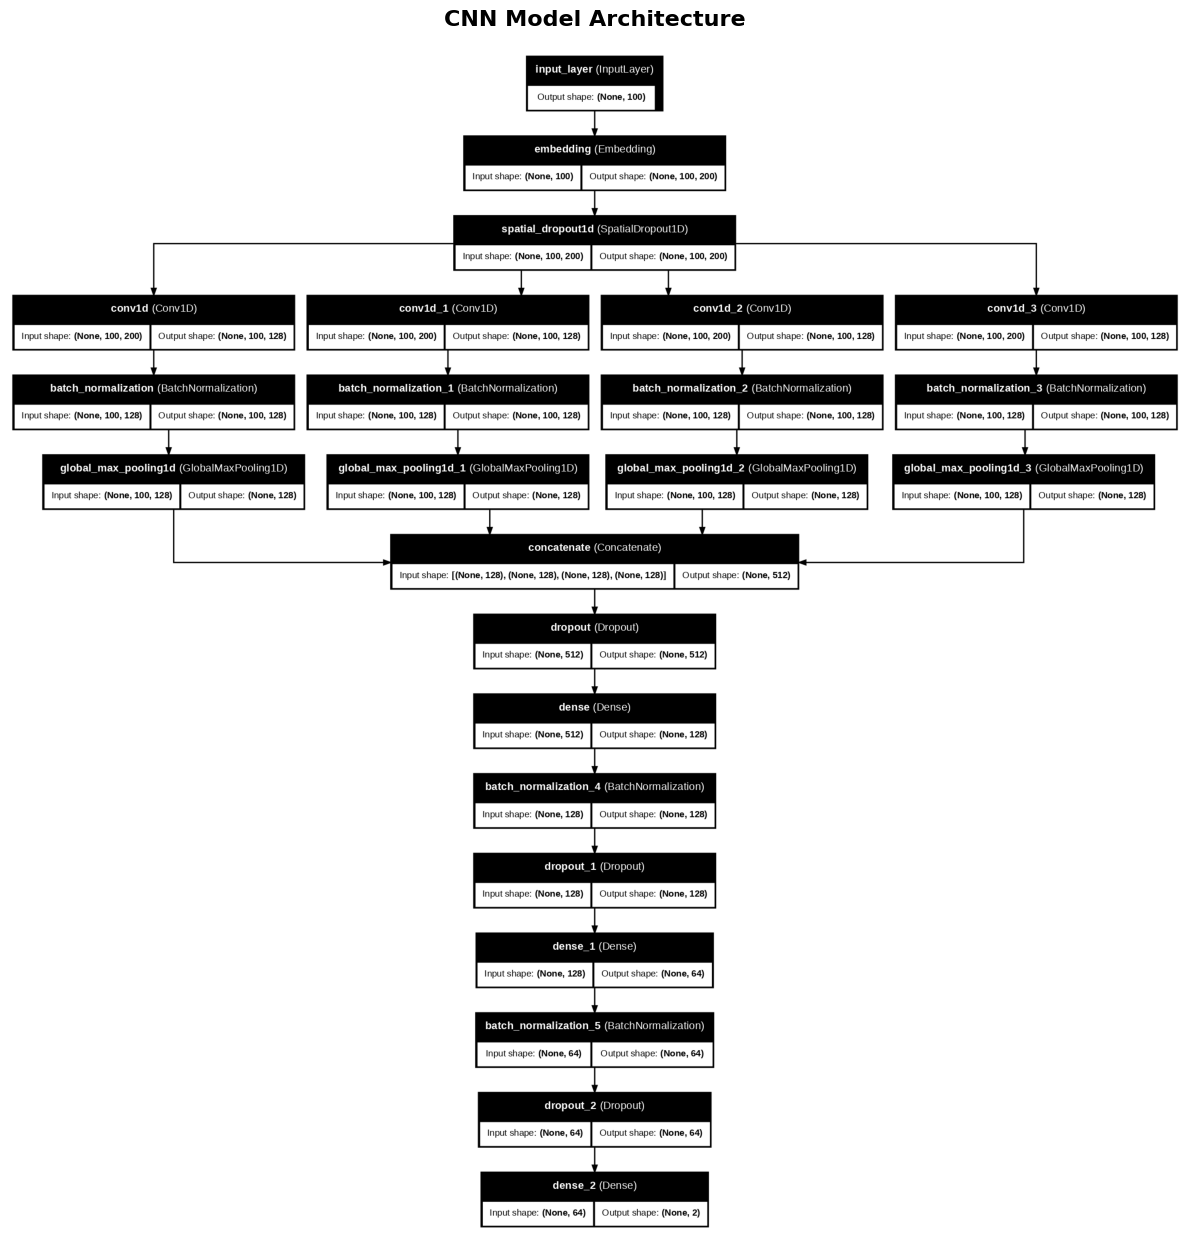

In [19]:
# Visualize model architecture
from tensorflow.keras.utils import plot_model

# Save model architecture plot
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True,
           rankdir='TB', dpi=100)

# Also create a simpler visualization
fig, ax = plt.subplots(figsize=(12, 15))
img = plt.imread('model_architecture.png')
ax.imshow(img)
ax.axis('off')
plt.title('CNN Model Architecture', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_architecture_display.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
# Define callbacks for training
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save best model
    ModelCheckpoint(
        'best_cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6098 - loss: 1.6300
Epoch 1: val_accuracy improved from None to 0.77575, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - accuracy: 0.6869 - loss: 1.2961 - val_accuracy: 0.7758 - val_loss: 0.8133 - learning_rate: 0.0010
Epoch 2/50
2049/2056 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7820 - loss: 0.7160
Epoch 2: val_accuracy improved from 0.77575 to 0.77982, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - accuracy: 0.7929 - loss: 0.6361 - val_accuracy: 0.7798 - val_loss: 0.5724 - learning_rate: 0.0010
Epoch 3/50
2052/2056 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8148 - loss: 0.5118
Epoch 3: val_accuracy did not improve from 0.77982
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8221 - loss: 0.5003 - val_accuracy: 0.7740 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 4/50
2052/2056 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8468 - loss: 0.4639
Epoch 4: val_accuracy did not improve from 0.77982
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8521 - loss: 0.4560 - val_accuracy: 0.7689 - val_loss: 0.6656 - learning_rate: 0.0010
Epoch 5/50
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8711 - loss: 0.4299
Epoch 5: val_accuracy did not improve from 0.77982
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8735 - loss: 0.4209 - val_accuracy: 0.76

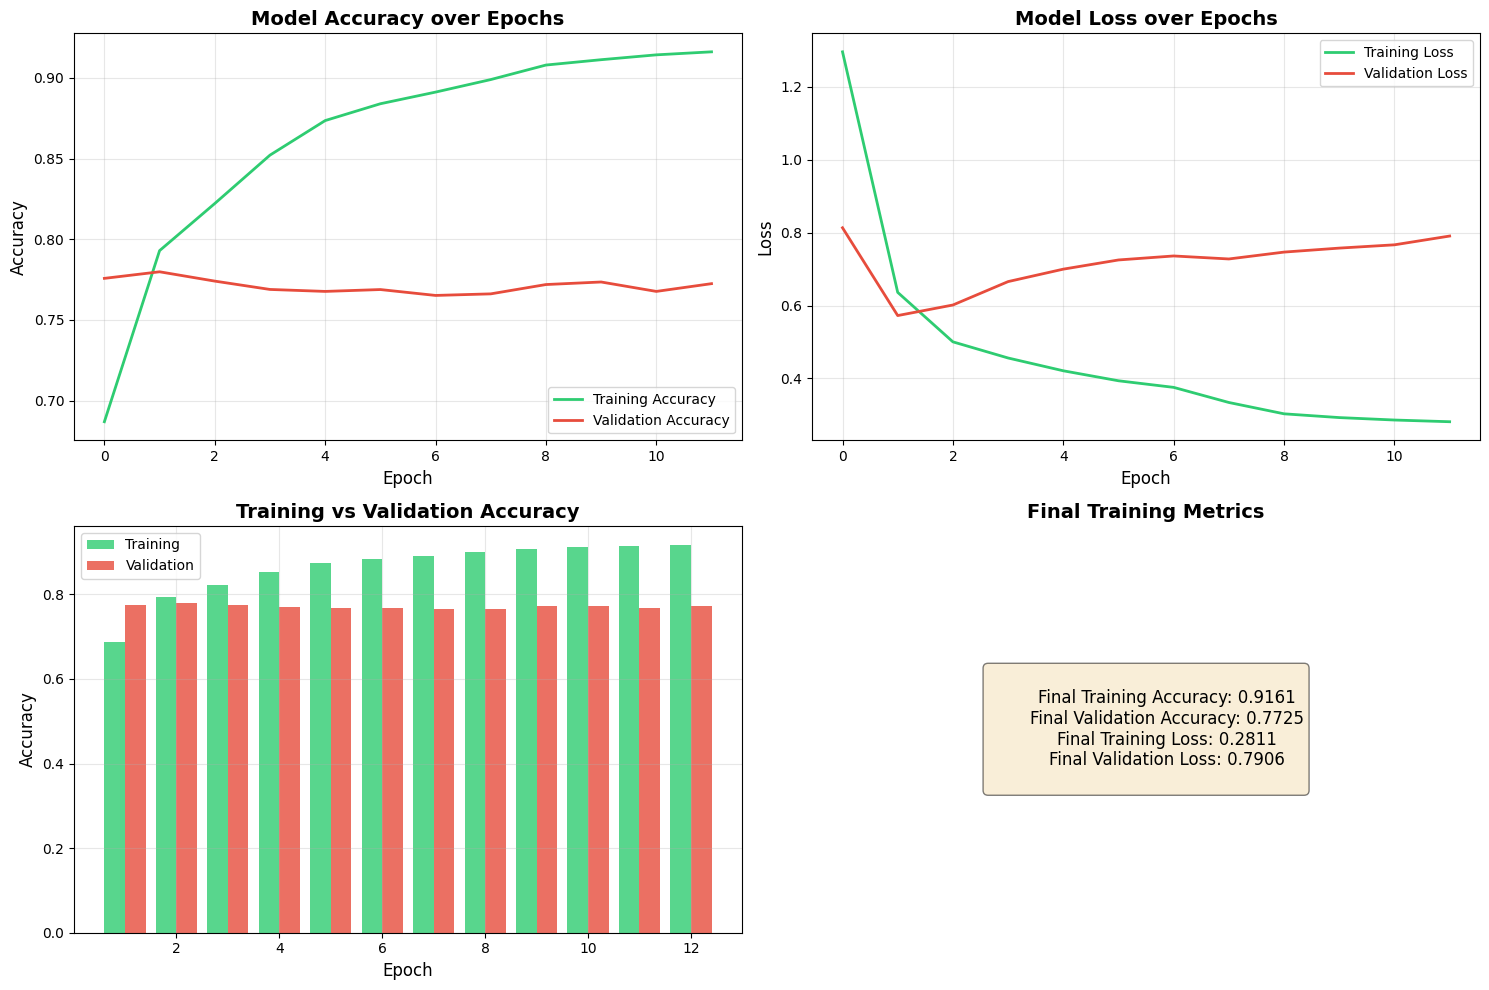

In [21]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy plot
    ax1 = axes[0, 0]
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2 = axes[0, 1]
    ax2.plot(history.history['loss'], label='Training Loss', color='#2ecc71', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Accuracy comparison
    ax3 = axes[1, 0]
    epochs = range(1, len(history.history['accuracy']) + 1)
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    ax3.bar(np.array(epochs) - 0.2, train_acc, width=0.4, label='Training', color='#2ecc71', alpha=0.8)
    ax3.bar(np.array(epochs) + 0.2, val_acc, width=0.4, label='Validation', color='#e74c3c', alpha=0.8)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Accuracy', fontsize=12)
    ax3.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Learning rate (if tracked)
    ax4 = axes[1, 1]
    if 'lr' in history.history:
        ax4.plot(history.history['lr'], color='#3498db', linewidth=2)
        ax4.set_xlabel('Epoch', fontsize=12)
        ax4.set_ylabel('Learning Rate', fontsize=12)
        ax4.set_title('Learning Rate over Epochs', fontsize=14, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    else:
        # Show final metrics
        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        metrics_text = f"""
        Final Training Accuracy: {final_train_acc:.4f}
        Final Validation Accuracy: {final_val_acc:.4f}
        Final Training Loss: {final_train_loss:.4f}
        Final Validation Loss: {final_val_loss:.4f}
        """
        ax4.text(0.5, 0.5, metrics_text, transform=ax4.transAxes, fontsize=12,
                verticalalignment='center', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax4.set_title('Final Training Metrics', fontsize=14, fontweight='bold')
        ax4.axis('off')

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [22]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred_proba = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# Per-class metrics
print("\nPer-Class Metrics:")
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(y_test, y_pred)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"\n{class_name}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall: {recall_per_class[i]:.4f}")
    print(f"  F1-Score: {f1_per_class[i]:.4f}")
    print(f"  Support: {support[i]}")

Test Accuracy: 0.7798
Test Loss: 0.5724
514/514 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Overall Metrics:
Accuracy: 0.7798
Precision (weighted): 0.7808
Recall (weighted): 0.7798
F1-Score (weighted): 0.7796

Per-Class Metrics:

Negative:
  Precision: 0.7972
  Recall: 0.7510
  F1-Score: 0.7734
  Support: 8228

Positive:
  Precision: 0.7643
  Recall: 0.8087
  F1-Score: 0.7859
  Support: 8218


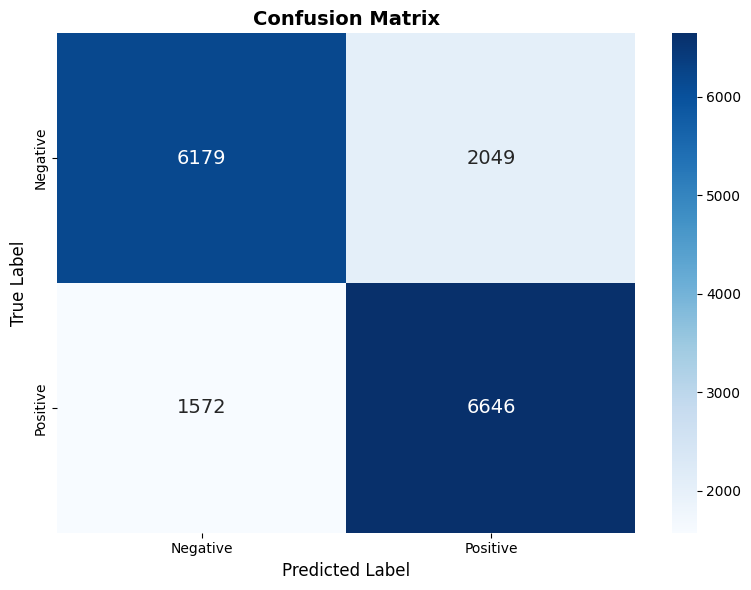

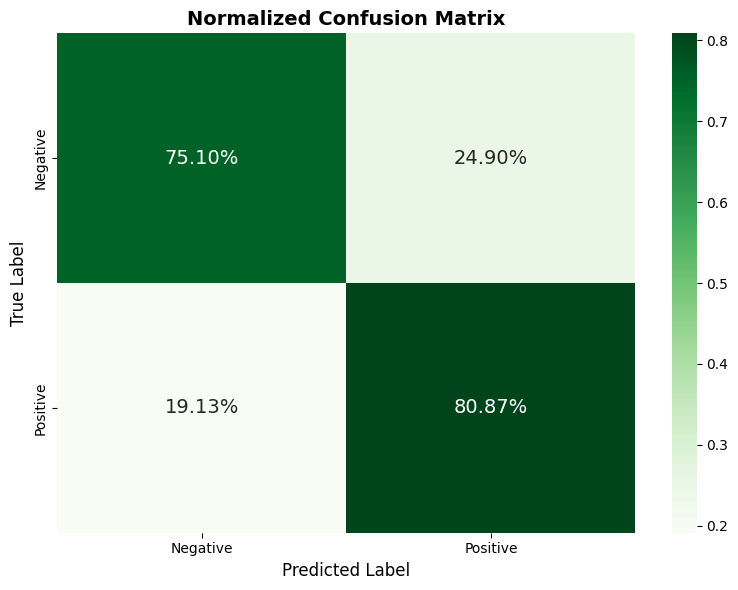

In [23]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.75      0.77      8228
    Positive       0.76      0.81      0.79      8218

    accuracy                           0.78     16446
   macro avg       0.78      0.78      0.78     16446
weighted avg       0.78      0.78      0.78     16446



In [23]:
# Plot ROC curves for each class
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#e74c3c']

for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.3f})')

# Plot diagonal
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves for Sentiment Classification', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\nAUC Scores:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {roc_auc[i]:.4f}")

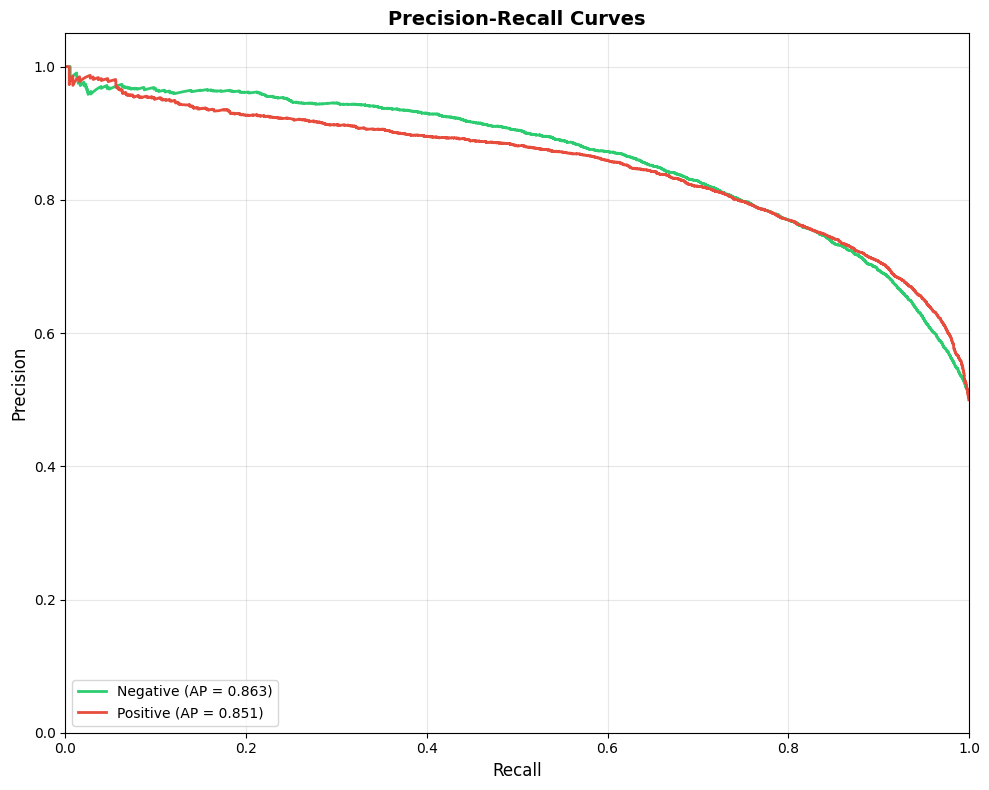


Average Precision Scores:
Negative: 0.8632
Positive: 0.8513


In [28]:
# Plot Precision-Recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get the number of classes from the label encoder
num_classes = len(label_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 8))

# Iterate over each class to plot its Precision-Recall curve
for i, color in zip(range(num_classes), colors):
    # Get true labels for the current class (1 if it's the current class, 0 otherwise)
    y_true_class = (y_test == i).astype(int)
    # Get predicted probabilities for the current class
    y_score_class = y_pred_proba[:, i]

    precision_curve, recall_curve, _ = precision_recall_curve(y_true_class, y_score_class)
    ap = average_precision_score(y_true_class, y_score_class)
    ax.plot(recall_curve, precision_curve, color=color, lw=2,
            label=f'{label_encoder.classes_[i]} (AP = {ap:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print Average Precision scores
print("\nAverage Precision Scores:")
for i in range(num_classes):
    y_true_class = (y_test == i).astype(int)
    y_score_class = y_pred_proba[:, i]
    ap = average_precision_score(y_true_class, y_score_class)
    print(f"{label_encoder.classes_[i]}: {ap:.4f}")

In [32]:


    # Add horizontal line

In [31]:
# Install scikeras to use Keras models with scikit-learn
!pip install scikeras

In [33]:
# Learning Curve Analysis
from sklearn.model_selection import learning_curve

# Create a simple model for learning curve (using Keras scikit-learn wrapper)
# The KerasClassifier has been moved to the scikeras library
from scikeras.wrappers import KerasClassifier

def create_model_for_learning_curve():
    return create_multi_filter_cnn(
        vocab_size=MAX_VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        max_length=MAX_SEQUENCE_LENGTH,
        num_classes=len(label_encoder.classes_)
    )

# Note: This is computationally expensive, so we'll use a smaller subset approach
def plot_learning_curves_simulated(history):
    """Plot learning curves from training history"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy learning curve
    ax1 = axes[0]
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax1.plot(epochs, history.history['accuracy'], 'o-', color='#2ecc71', linewidth=2,
             markersize=4, label='Training')
    ax1.plot(epochs, history.history['val_accuracy'], 'o-', color='#e74c3c', linewidth=2,
             markersize=4, label='Validation')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Learning Curve - Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)